# AlphaLens Point-in-Time Earnings Surprises

This notebook audits reported-versus-estimated EPS before the features enter a tree model. Yahoo calendar percentages are normalized to decimal rates, future estimate-only rows are excluded, and results can match only an earnings call within three calendar days when the result was observable by the feature anchor.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sqlalchemy import text

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pipelines.ml.dataset import get_database_engine
from pipelines.ml.features import build_event_feature_dataset

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 30)

## Source coverage

In [2]:
engine = get_database_engine()
coverage = pd.read_sql_query(text('''
    SELECT ticker, COUNT(*) AS results,
           MIN(earnings_date) AS oldest, MAX(earnings_date) AS newest,
           COUNT(eps_surprise_pct) AS surprise_values
    FROM earnings_results
    GROUP BY ticker
    ORDER BY ticker
'''), engine)
display(coverage)

,ticker,results,oldest,newest,surprise_values
0,AAPL,24,2020-10-29,2026-07-30,24
1,AMZN,24,2020-10-29,2026-07-30,24
2,BA,24,2020-10-28,2026-07-28,24
3,BAC,24,2020-10-14,2026-07-14,24
4,CAT,24,2020-10-27,2026-08-04,24
5,COST,24,2020-09-24,2026-05-28,24
6,CVX,24,2020-10-30,2026-07-31,24
7,GOOGL,24,2020-10-29,2026-07-22,24
8,GS,24,2020-10-14,2026-07-14,24
9,JNJ,24,2020-10-13,2026-07-15,24


outcome
Beat    393
Miss     87
Name: events, dtype: int64

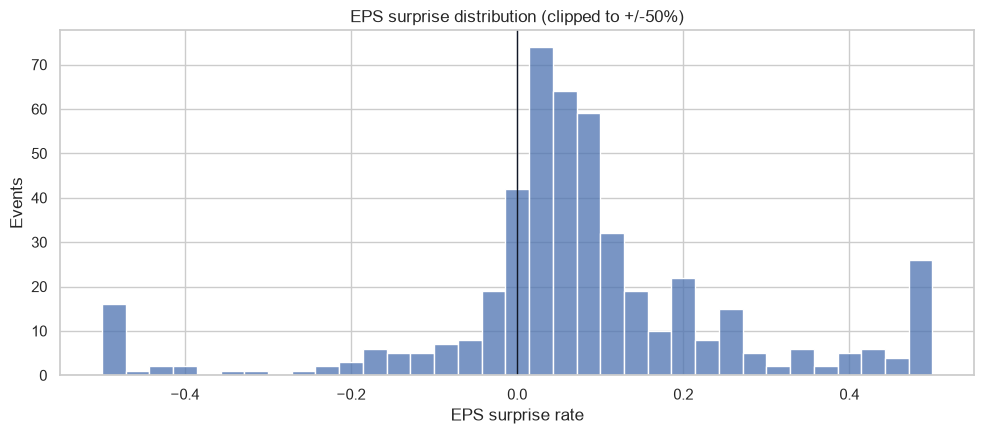

In [3]:
results = pd.read_sql_query(text('''
    SELECT ticker, earnings_date, eps_estimate, reported_eps, eps_surprise_pct
    FROM earnings_results
    ORDER BY earnings_date, ticker
'''), engine)
results['outcome'] = results['eps_surprise_pct'].map(
    lambda value: 'Beat' if value > 0 else ('Miss' if value < 0 else 'Met')
)
display(results['outcome'].value_counts(dropna=False).rename('events'))
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.histplot(results['eps_surprise_pct'].clip(-0.5, 0.5), bins=35, ax=ax)
ax.axvline(0, color='#111827', linewidth=1)
ax.set(title='EPS surprise distribution (clipped to +/-50%)', xlabel='EPS surprise rate', ylabel='Events')
plt.tight_layout()
plt.show()

## Point-in-time call matches

SEC filing rows remain null by design. The table below measures how many earnings calls receive a bounded result match and whether provider dates differ from transcript dates.

In [4]:
features = build_event_feature_dataset(horizon=30, include_topics=True)
calls = features.loc[features['event_source'] == 'earnings_call'].copy()
match_summary = pd.Series({
    'earnings_calls': len(calls),
    'matched_results': calls['reported_eps'].notna().sum(),
    'match_coverage': calls['reported_eps'].notna().mean(),
    'max_match_days': calls['earnings_result_match_days'].max(),
})
display(match_summary)
display(calls['earnings_result_match_days'].value_counts(dropna=False).sort_index())

earnings_calls     359.000000
matched_results    356.000000
match_coverage       0.991643
max_match_days       0.000000
dtype: float64

earnings_result_match_days
0.0    356
NaN      3
Name: count, dtype: int64

In [5]:
display(calls.loc[calls['reported_eps'].notna(), [
    'ticker', 'event_date', 'fiscal_period', 'earnings_result_date',
    'eps_estimate', 'reported_eps', 'eps_surprise_pct',
    'prior_eps_surprise_pct', 'eps_surprise_change',
]].sort_values('event_date', ascending=False).head(25))

,ticker,event_date,fiscal_period,earnings_result_date,eps_estimate,reported_eps,eps_surprise_pct,prior_eps_surprise_pct,eps_surprise_change
752,CAT,2026-08-04,2026Q2,2026-08-04,6.20,8.17,0.3183,0.1930,0.1253
750,CVX,2026-07-31,2026Q2,2026-07-31,5.57,6.06,0.0884,0.4556,-0.3672
745,AMZN,2026-07-30,2026Q2,2026-07-30,1.83,5.75,2.1502,0.6818,1.4684
744,AAPL,2026-07-30,2026Q3,2026-07-30,1.89,2.02,0.0674,0.0346,0.0328
743,PG,2026-07-29,2026Q4,2026-07-29,1.41,1.43,0.0155,0.0222,-0.0067
741,MSFT,2026-07-29,2026Q4,2026-07-29,4.24,4.74,0.1181,0.0490,0.0691
740,META,2026-07-29,2026Q2,2026-07-29,7.22,6.18,-0.1442,0.5679,-0.7121
738,KO,2026-07-28,2026Q2,2026-07-28,0.93,0.97,0.0405,0.0588,-0.0183
736,BA,2026-07-28,2026Q2,2026-07-28,-0.31,-0.76,-1.4148,0.7026,-2.1174
731,GOOGL,2026-07-22,2026Q2,2026-07-22,2.90,9.11,2.1423,0.9159,1.2264


## Modeling decision

The approved features use only announced values available by the anchor session. Missing values are meaningful: SEC filings have no direct surprise feature, and unmatched calls remain null rather than receiving a fabricated zero. The chronological model pipeline performs imputation inside each training fold.